            # Week 4 - Hypothesis Testing Using SciPy and StatsModels

            This notebook adapts the hypothesis-testing hands-on exercise to the driving-behavior motion dataset instead of the `tips` sample dataset.

            ## Dataset context

            We use sensor-derived variables such as:
            - `acc_mag` for acceleration intensity
            - `gyro_mag` for turning or rotation intensity
            - `driver_rating_proxy` as a dashboard-friendly rating score derived from trip severity

            ## Questions tested

            1. Is the average acceleration magnitude significantly different from `1.40`?
            2. Do aggressive and slow trips have different average acceleration magnitudes?
            3. Is the average acceleration magnitude different from the average gyroscope magnitude within the same trips?
            4. Do trip-level ratings differ across `SLOW`, `NORMAL`, and `AGGRESSIVE` groups?
            5. Are `risk_level` and `coaching_priority` independent?
            6. What is the 95% confidence interval for the average rating proxy?
            


In [1]:
            !pip install pandas numpy matplotlib seaborn scipy statsmodels
            


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 11.9 MB/s  0:00:01 eta 0:00:01:0101
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] 1/2 [statsmodels]


In [2]:
            from pathlib import Path
            import numpy as np
            import pandas as pd
            import seaborn as sns
            import matplotlib.pyplot as plt
            from scipy import stats
            from scipy.stats import chi2_contingency
            import statsmodels.stats.api as sms

            BASE_DIR = Path(r"/Users/ayet_dub/Documents/Codex/2026-05-11/files-mentioned-by-the-user-test")
            sensor_df = pd.read_csv(BASE_DIR / "data" / "motion_sensor_enriched.csv")
            trip_df = pd.read_csv(BASE_DIR / "data" / "telematics_trip_summary.csv")
            driver_df = pd.read_csv(BASE_DIR / "data" / "driver_profile_dashboard.csv")
            


In [3]:
            print(sensor_df.head())
            print(sensor_df[["acc_mag", "gyro_mag", "jerk_mag"]].describe())
            print(trip_df[["driver_rating_proxy", "violation_score"]].describe())
            


       AccX      AccY      AccZ     GyroX     GyroY     GyroZ       Class  \
0  0.758194 -0.217791  0.457263  0.000000  0.000000  0.000000  AGGRESSIVE   
1  0.667560 -0.038610  0.231416 -0.054367 -0.007712  0.225257  AGGRESSIVE   
2  2.724449 -7.584121  2.390926  0.023824  0.013668 -0.038026  AGGRESSIVE   
3  2.330950 -7.621754  2.529024  0.056810 -0.180587 -0.052076  AGGRESSIVE   
4  2.847215 -6.755621  2.224640 -0.031765 -0.035201  0.035277  AGGRESSIVE   

   Timestamp source_split   acc_mag  ...  prev_acc_mag  prev_gyro_mag  \
0     818922         test  0.911801  ...           NaN            NaN   
1     818923         test  0.707588  ...      0.911801       0.000000   
2     818923         test  8.405834  ...      0.707588       0.231853   
3     818924         test  8.361843  ...      8.405834       0.046908   
4     818924         test  7.661206  ...      8.361843       0.196344   

   delta_t  jerk_mag  gyro_delta  row_in_split  trip_seq       trip_id  \
0      0.0  0.000000    

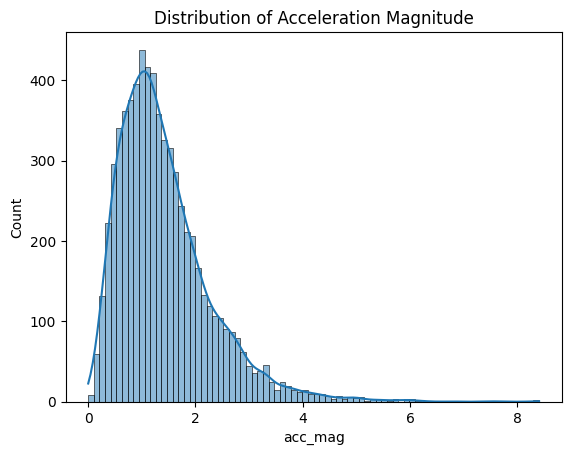

In [4]:
            sns.histplot(sensor_df["acc_mag"], kde=True)
            plt.title("Distribution of Acceleration Magnitude")
            plt.show()
            


            ## Part 1: One-sample t-test

            **H0:** The mean acceleration magnitude is equal to `1.40`  
            **H1:** The mean acceleration magnitude is not equal to `1.40`
            


In [5]:
            t_stat, p_val = stats.ttest_1samp(sensor_df["acc_mag"], 1.40)
            print("One-sample t-test")
            print("T-statistic:", t_stat)
            print("P-value:", p_val)
            


One-sample t-test
T-statistic: 1.7521578437150624
P-value: 0.0797922297882809


            ## Part 2: Two-sample independent t-test

            H0: Aggressive and slow trips have the same mean acceleration magnitude  
            H1: They have different mean acceleration magnitudes
            


In [6]:
            aggressive = trip_df.loc[trip_df["trip_label"] == "AGGRESSIVE", "avg_acc_mag"]
            slow = trip_df.loc[trip_df["trip_label"] == "SLOW", "avg_acc_mag"]

            t_stat, p_val = stats.ttest_ind(aggressive, slow, equal_var=False)
            print("Independent t-test")
            print("T-statistic:", t_stat)
            print("P-value:", p_val)
            


Independent t-test
T-statistic: 6.761127620828994
P-value: 1.500547418021277e-08


            ## Part 3: Paired t-test

            We compare `avg_acc_mag` and `avg_gyro_mag` inside the same trips.

            H0: The mean paired difference is zero  
            H1: The mean paired difference is not zero
            


In [7]:
            t_stat, p_val = stats.ttest_rel(trip_df["avg_acc_mag"], trip_df["avg_gyro_mag"])
            print("Paired t-test")
            print("T-statistic:", t_stat)
            print("P-value:", p_val)
            


Paired t-test
T-statistic: 36.88604221973941
P-value: 1.7258982318809466e-64


            ## Part 4: One-way ANOVA

            **H0:** Average rating proxy is the same across trip classes  
            **H1:** At least one class has a different mean rating proxy
            


In [8]:
            grouped = [group["driver_rating_proxy"].values for _, group in trip_df.groupby("trip_label")]
            f_stat, p_val = stats.f_oneway(*grouped)
            print("ANOVA")
            print("F-statistic:", f_stat)
            print("P-value:", p_val)
            


ANOVA
F-statistic: 313.60534363661196
P-value: 3.622917505538578e-46


            ## Part 5: Chi-square test of independence

            H0: `risk_level` and `coaching_priority` are independent  
            H1: They are associated
            


In [9]:
            contingency = pd.crosstab(driver_df["risk_level"], driver_df["coaching_priority"])
            chi2, p, dof, expected = chi2_contingency(contingency)
            print("Chi-square statistic:", chi2)
            print("P-value:", p)
            print("Degrees of freedom:", dof)
            print("Expected frequencies:\n", expected)
            


Chi-square statistic: 12.666666666666668
P-value: 0.0017761035457343783
Degrees of freedom: 2
Expected frequencies:
 [[2.5 2.5]
 [3.5 3.5]
 [3.  3. ]]


            ## Part 6: StatsModels confidence interval
            


In [10]:
            ci = sms.DescrStatsW(trip_df["driver_rating_proxy"]).tconfint_mean()
            print("95% confidence interval for the mean driver rating proxy:", ci)
            


95% confidence interval for the mean driver rating proxy: (np.float64(3.292882888452906), np.float64(3.6241082619895715))


Most of the tests showed significant results, meaning there are real differences or relationships in the driver data. Only Part 1 was not significant, so the mean acceleration magnitude was not proven to be different from 1.40.

The results show that aggressive and slow trips are different, acceleration and gyro movement measure different driving behaviors, driver ratings vary by trip class, and risk level is related to coaching priority.

Overall, the findings support using the monitoring system to group drivers by behavior, identify higher-risk drivers, and decide who may need coaching or further review.